# 311 Service Requests Analysis

For my portion of the final project, I decided to analyze 311 non-emergency service requests across Pittsburgh neighborhoods. These are things like pothole reports, graffiti, litter, and other complaints that residents call in. I am measuring this by counting the amount of 311 requests each neighborhood has, and concluding that the fewer requests is the better neighborhood.

**Dataset:** https://data.wprdc.org/dataset/311-data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Loading the Data

In [19]:
df = pd.read_csv("29462525-62a6-45bf-9b5e-ad2e1c06348d.csv")
df.head()

,_id,group_id,num_requests,parent_closed,status_name,status_code,dept,request_type_name,request_type_id,create_date_et,...,cross_street_id,city,neighborhood,census_tract,council_district,ward,police_zone,latitude,longitude,geo_accuracy
0,1,827262,1,f,open,0,DPW - Administration,Park Shelter,543,2024-03-12T10:50:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
1,2,720661,1,f,open,0,DPW - Administration,Park Shelter,543,2023-03-20T07:52:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
2,3,722010,1,f,open,0,DPW - Administration,Park Shelter,543,2023-03-24T07:44:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
3,4,846915,1,f,open,0,Police - Zones 1-6,Illegal Parking,417,2024-05-19T12:24:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
4,5,853708,1,f,open,0,DPW - Facilities,City Facility,375,2024-06-06T23:04:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES


# Exploring the Data

In [23]:
print(f"Total 311 requests: {len(df)}")
print(f"Number of unique neighborhoods: {df['neighborhood'].nunique()}")

Total 311 requests: 815417
Number of unique neighborhoods: 91


## Most common types of 311 requests

In [24]:
df['request_type_name'].value_counts().head(10)

request_type_name
Weeds/Debris                            77513
Potholes                                67502
Missed Refuse Pick Up                   42185
Snow/Ice removal                        34942
Building Maintenance                    28863
Refuse Violations                       26598
Abandoned Vehicle (parked on street)    23768
Illegal Parking                         21289
Missed Recycling Pick Up                17987
Street Light - Repair                   17903
Name: count, dtype: int64

# Counting Complaints by Neighborhood
Here I'm grouping all the requests by neighborhood and counting how many each one has to see which neighborhoods have the most and fewest complaints.

In [26]:
# Drop rows with no neighborhood
df = df.dropna(subset=['neighborhood'])
df = df[df['neighborhood'] != '']

# Count requests per neighborhood
counts = df.groupby('neighborhood').size().reset_index(name='total_requests')
counts = counts.sort_values('total_requests', ascending=False)
counts

,neighborhood,total_requests
13,Brookline,32245
15,Carrick,31017
72,South Side Flats,29758
73,South Side Slopes,29508
77,Squirrel Hill South,29226
...,...,...
67,Ridgemont,909
58,Northview Heights,836
35,Glen Hazel,477
4,Arlington Heights,167


# Visualization of Data

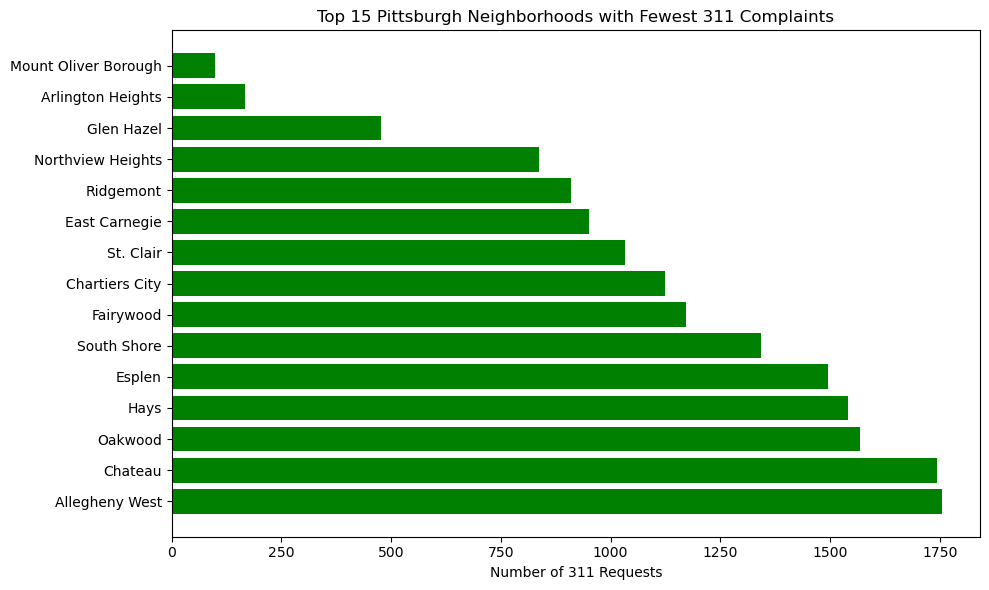

In [27]:
best_15 = counts.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(best_15['neighborhood'], best_15['total_requests'], color='green')
plt.xlabel('Number of 311 Requests')
plt.title('Top 15 Pittsburgh Neighborhoods with Fewest 311 Complaints')
plt.tight_layout()
plt.show()

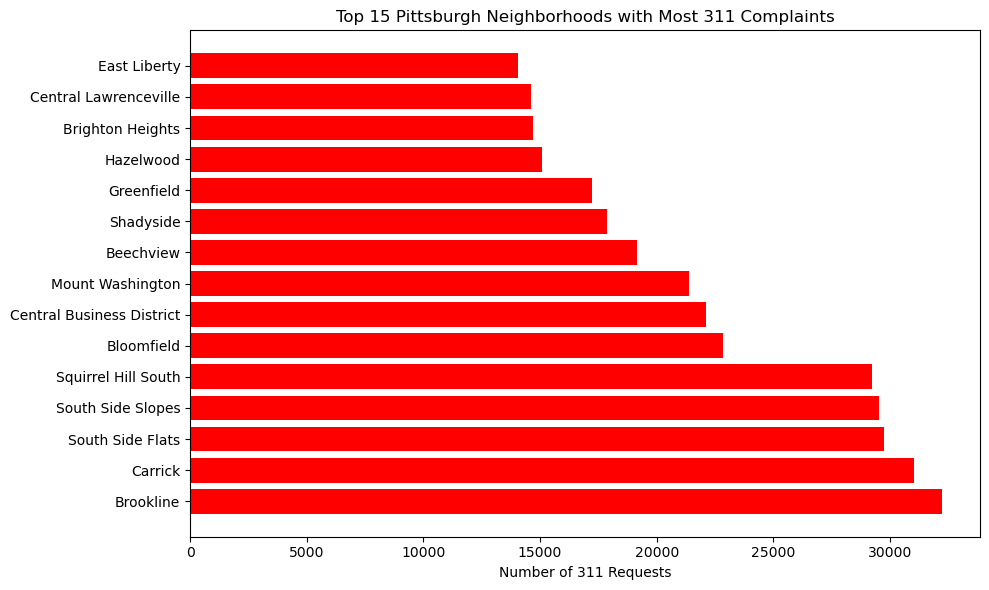

In [28]:
worst_15 = counts.head(15)

plt.figure(figsize=(10, 6))
plt.barh(worst_15['neighborhood'], worst_15['total_requests'], color='red')
plt.xlabel('Number of 311 Requests')
plt.title('Top 15 Pittsburgh Neighborhoods with Most 311 Complaints')
plt.tight_layout()
plt.show()

## Best Neighborhood

In [30]:
best = counts.tail(1)
print(f"Best neighborhood by 311 requests: {best['neighborhood'].values[0]} with {best['total_requests'].values[0]} requests")

Best neighborhood by 311 requests: Mount Oliver Borough with 98 requests


## Conclusion

Based on the 311 data per neighborhood, Mount Oliver Borough has the least complaints with only 98 requests, making it the "best" neighborhood according to this metric of data and Arlington Heights in second with 167 requests. Brookline and Carrick had the most complaints with over 30,000 each. A point of concern with this metric is that neighborhoods with fewer residents will naturally have fewer complaints, so a smaller neighborhood having less requests doesn't necessarily mean it's a better place to live. Despite this, the data gives the general idea of which neighborhoods have more issues being reported.  I don't have a personal favorite neighborhood in Pittsburgh yet since I'm still getting to know the city, but based on the data Mount Oliver Borough seems like a very nice place to live.
